# Understanding the Calculation of Strain Rates

**Bodo Bookhagen (bodo.bookhagen@uni-potsdam.de)**


Strain rate analysis transforms raw GNSS velocity vectors—which measure absolute motion relative to a reference frame—into a measurement of **deformation** within Earth's crust. 

If two adjacent GNSS stations move at the exact same velocity, the region between them moves as a rigid body and experiences zero strain. Strain occurs only when there is a **gradient** (a spatial change) in velocity between stations.

![Pure shear vs simple shear deformation.](compression_shear.png)


---

## 1. Mathematical Foundation

When you calculate spatial velocity gradients, the 2D velocity gradient tensor $\mathbf{L} = \nabla \mathbf{V}$ is decomposed into two parts:

$$\mathbf{L} = \begin{bmatrix} \frac{\partial V_e}{\partial x} & \frac{\partial V_e}{\partial y} \\[6pt] \frac{\partial V_n}{\partial x} & \frac{\partial V_n}{\partial y} \end{bmatrix} = \underbrace{\dot{\boldsymbol{\epsilon}}}_{\text{Strain Rate (Symmetric)}} + \underbrace{\dot{\boldsymbol{\omega}}}_{\text{Vorticity (Antisymmetric)}}$$

### Component Breakdown

* **Normal Strain Rates ($\dot{\epsilon}_{xx}$ and $\dot{\epsilon}_{yy}$):**
  $$\dot{\epsilon}_{xx} = \frac{\partial V_e}{\partial x}, \quad \dot{\epsilon}_{yy} = \frac{\partial V_n}{\partial y}$$
  * **Meaning:** Change in length per unit time along the East-West and North-South axes.
  * **Interpretation:** Positive values represent **extension** (stretching); negative values represent **compression** (shortening).

* **Shear Strain Rate ($\dot{\epsilon}_{xy}$):**
  $$\dot{\epsilon}_{xy} = \frac{1}{2}\left(\frac{\partial V_e}{\partial y} + \frac{\partial V_n}{\partial x}\right)$$
  * **Meaning:** Change in angle between two orthogonal line segments.
  * **Interpretation:** Measures how an initially square block of crust is distorted into a parallelogram (typical along strike-slip faults like the San Andreas Fault).

* **Rigid-Body Rotation / Vorticity ($\dot{\omega}$):**
  $$\dot{\omega} = \frac{1}{2}\left(\frac{\partial V_n}{\partial x} - \frac{\partial V_e}{\partial y}\right)$$
  * **Meaning:** The antisymmetric component of the velocity gradient tensor.
  * **Interpretation:** Spin without physical deformation. It quantifies how much a block of crust rotates clockwise or counterclockwise as a solid unit relative to its surroundings.

---

## 2. Invariants (Coordinate-Independent Quantities)

Because arbitrary coordinate rotation shouldn't alter physical conclusions, geoscientists rely on **invariants**:

| Invariant | Equation | Geodynamic Meaning |
| :--- | :--- | :--- |
| **Dilatational Strain Rate** | $\dot{\epsilon}_{\text{dil}} = \dot{\epsilon}_{xx} + \dot{\epsilon}_{yy}$ | **Area change over time.** Measures net volumetric expansion (rifts) or contraction (subduction). |
| **Maximum Shear Strain Rate** | $\dot{\epsilon}_{\text{max}} = \sqrt{\left(\frac{\dot{\epsilon}_{xx} - \dot{\epsilon}_{yy}}{2}\right)^2 + \dot{\epsilon}_{xy}^2}$ | **Maximum rate of angular distortion.** Highlights active fault traces and seismic strain accumulation. |
| **Principal Strain Rates** | $\dot{\epsilon}_{1,2} = \frac{\dot{\epsilon}_{xx} + \dot{\epsilon}_{yy}}{2} \pm \dot{\epsilon}_{\text{max}}$ | **Max and min extension rates.** Defines the axes of the deformation strain ellipse. |

---

## 3. Geodynamic Applications

1. **Identifying Hidden Faults:** GNSS velocities vary smoothly overall, but strain rate spikes sharply over locked or slipping fault zones.
2. **Earthquake Hazard Mapping:** Strain rate directly correlates with tectonic stress accumulation. High maximum shear strain pinpoints zones storing elastic strain energy that will eventually release in seismic events.
3. **Volcanology & Rifting:** Dilatational strain locates magma accumulation (inflation/expansion) or deflation near volcanic centers, as well as active rift zones.

---
## 4. Understanding the Vorticity Term in Spatial Derivatives

When computing the 2D spatial velocity gradient matrix $\mathbf{L} = \nabla \mathbf{V}$ from GNSS velocities:

$$\mathbf{L} = \begin{bmatrix} \frac{\partial V_e}{\partial x} & \frac{\partial V_e}{\partial y} \\[6pt] \frac{\partial V_n}{\partial x} & \frac{\partial V_n}{\partial y} \end{bmatrix}$$

This matrix is decomposed into a **symmetric part** ($\dot{\boldsymbol{\epsilon}}$, strain rate tensor) and an **antisymmetric part** ($\dot{\boldsymbol{\omega}}$, spin/vorticity tensor):

$$\mathbf{L} = \dot{\boldsymbol{\epsilon}} + \dot{\boldsymbol{\omega}} = \begin{bmatrix} \dot{\epsilon}_{xx} & \dot{\epsilon}_{xy} \\ \dot{\epsilon}_{xy} & \dot{\epsilon}_{yy} \end{bmatrix} + \begin{bmatrix} 0 & -\dot{\omega} \\ \dot{\omega} & 0 \end{bmatrix}$$

---

### 4.1. What Is the Vorticity ($\dot{\omega}$) Term?

The scalar vorticity term $\dot{\omega}$ is defined as:

$$\dot{\omega} = \frac{1}{2} \left( \frac{\partial V_n}{\partial x} - \frac{\partial V_e}{\partial y} \right)$$

* **Physical Meaning:** It measures **rigid-body rotation** of a region about a vertical axis. 
* **Key Characteristic:** It describes motion **without changing shape or area**. If a crustal block rotates like a vinyl on a turntable, $\dot{\omega} \neq 0$, but all strain rate components ($\dot{\epsilon}_{xx}, \dot{\epsilon}_{yy}, \dot{\epsilon}_{xy}$) are **zero**.

---

### 4.2. Distinction: Strain vs. Vorticity

To understand the practical difference, consider how simple shear and pure rotation behave:

| Deformation Type | Velocity Gradients | Strain Rate ($\dot{\epsilon}_{xy}$) | Vorticity ($\dot{\omega}$) | Physical Effect |
| :--- | :--- | :--- | :--- | :--- |
| **Pure Rigid Rotation** | $\frac{\partial V_n}{\partial x} = -\frac{\partial V_e}{\partial y} = \Omega$ | **$0$** | **$\Omega$** | Block spins as a solid unit; no distortion or stress accumulation. |
| **Simple Shear** (e.g., Strike-Slip Fault) | $\frac{\partial V_e}{\partial y} = k, \quad \frac{\partial V_n}{\partial x} = 0$ | **$\frac{1}{2}k$** | **$-\frac{1}{2}k$** | Block both distorts into a parallelogram **and** rotates simultaneously. |
| **Pure Shear** (e.g., Orthogonal Extension) | $\frac{\partial V_e}{\partial y} = \frac{\partial V_n}{\partial x} = k$ | **$k$** | **$0$** | Block changes shape without any net rotation. |

---

### 4.3. Why Is Vorticity Critical in Geodesy?

1. **Reference Frame Dependency:** 
   * Absolute velocities ($V_e, V_n$) depend on the terrestrial reference frame (e.g., ITRF2014 vs. a stable plate frame).
   * **Strain rate ($\dot{\boldsymbol{\epsilon}}$) is reference-frame invariant**—it stays the same regardless of frame choice.
   * **Vorticity ($\dot{\omega}$) is reference-frame dependent**—changing the global reference frame adds or subtracts a uniform rotation constant to $\dot{\omega}$.

2. **Microplate & Crustal Block Kinematics:** 
   * Tectonic microplates (like the Anatolian Block in Turkey or the Oregon Coast Block) undergo fast rigid-body rotations driven by surrounding plate interactions. Vorticity quantifies these rotation rates in radians per year or degrees per million years.

3. **Distinguishing Strain Accumulation from Block Motion:** 
   * Seismic risk comes from **strain rate** ($\dot{\boldsymbol{\epsilon}}$), which measures stored elastic strain energy.
   * Vorticity ($\dot{\omega}$) indicates how much motion is absorbed harmlessly as rigid rotation rather than building up strain on faults.

# Calculating spatial derivatives for three points and three velocities

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Coordinates of the 3 GNSS stations (in meters)
x = np.array([0.0, 50000.0, 10000.0])
y = np.array([0.0, 5000.0, 45000.0])

# 2. Measured horizontal velocities (in meters/year)
Vx = np.array([0.010, 0.012, 0.008])
Vy = np.array([0.005, 0.003, 0.009])

# Calculate relative coordinates (Station 0 serves as the local origin)
dx = x - x[0]
dy = y - y[0]

# 3. Construct Design Matrix A (6x6) and Observation Vector L (6x1)
A = np.zeros((6, 6))
L = np.zeros((6, 1))

for i in range(3):
    # Rows for East velocity (Vx)
    A[2*i, 0] = 1.0     # Translation V_x0
    A[2*i, 2] = dx[i]   # Gradient dVx/dx
    A[2*i, 3] = dy[i]   # Gradient dVx/dy
    L[2*i, 0] = Vx[i]
    
    # Rows for North velocity (Vy)
    A[2*i+1, 1] = 1.0   # Translation V_y0
    A[2*i+1, 4] = dx[i] # Gradient dVy/dx
    A[2*i+1, 5] = dy[i] # Gradient dVy/dy
    L[2*i+1, 0] = Vy[i]

# 4. Solve the system of equations (AX = L -> X = A^-1 * L)
X = np.linalg.solve(A, L)
Vx0, Vy0, dVxdx, dVxdy, dVydx, dVydy = X.flatten()

# 5. Calculate Strain components
dilatation = dVxdx + dVydy
gamma_1 = dVxdx - dVydy
gamma_2 = dVxdy + dVydx
gamma_max = np.sqrt(gamma_1**2 + gamma_2**2)
rotation = 0.5 * (dVydx - dVxdy)

to_nanostrain = 1e9

print("--- Results: Inversion for 3 Stations ---")
print(f"Dilatation (Areal Strain): {dilatation * to_nanostrain:+.2f} nstrain/yr")
print(f"Pure Shear (gamma_1): {gamma_1 * to_nanostrain:+.2f} nstrain/yr")
print(f"Engineering Shear (gamma_2): {gamma_2 * to_nanostrain:+.2f} nstrain/yr")
print(f"Maximum Total Shear: {gamma_max * to_nanostrain:.2f} nstrain/yr")
print(f"Rigid Block Rotation: {rotation * to_nanostrain:+.2f} nrad/yr")

--- Results: Inversion for 3 Stations ---
Dilatation (Areal Strain): +145.45 nstrain/yr
Pure Shear (gamma_1): -54.55 nstrain/yr
Engineering Shear (gamma_2): -104.55 nstrain/yr
Maximum Total Shear: 117.92 nstrain/yr
Rigid Block Rotation: +2.27 nrad/yr


# Step-by-Step explanation:

This following explains the mathematical model, matrix formulation, and step-by-step calculations performed by the 3-station GNSS strain inversion script (Python code above).

---

## 1. Underlying Mathematical Model

For a small triangular network, horizontal velocities ($V_x, V_y$) are modeled as a **first-order Taylor series expansion** (linear surface deformation model) relative to a reference origin $(x_0, y_0)$:

$$V_x(x, y) = V_{x0} + \frac{\partial V_x}{\partial x} \Delta x + \frac{\partial V_x}{\partial y} \Delta y$$

$$V_y(x, y) = V_{y0} + \frac{\partial V_y}{\partial x} \Delta x + \frac{\partial V_y}{\partial y} \Delta y$$

where:

* $\Delta x = x_i - x_0$ and $\Delta y = y_i - y_0$ are relative coordinates.
* $V_{x0}, V_{y0}$ are rigid-body translations at the origin.
* $\frac{\partial V_x}{\partial x}, \frac{\partial V_x}{\partial y}, \frac{\partial V_y}{\partial x}, \frac{\partial V_y}{\partial y}$ are velocity spatial gradients.

---

## 2. Matrix Formulation ($A \cdot X = L$)

Since 3 stations provide 6 independent observation equations (2 velocity components per station) to estimate 6 unknown parameters, the system forms a **determinate linear matrix system** of the form $\mathbf{A} \mathbf{X} = \mathbf{L}$.

### Parameter Vector ($\mathbf{X}$)

$$\mathbf{X} = \begin{bmatrix} V_{x0} \\ V_{y0} \\ \frac{\partial V_x}{\partial x} \\ \frac{\partial V_x}{\partial y} \\ \frac{\partial V_y}{\partial x} \\ \frac{\partial V_y}{\partial y} \end{bmatrix}_{6 \times 1}$$

### Observation Vector ($\mathbf{L}$)

$$\mathbf{L} = \begin{bmatrix} V_{x,0} \\ V_{y,0} \\ V_{x,1} \\ V_{y,1} \\ V_{x,2} \\ V_{y,2} \end{bmatrix} = \begin{bmatrix} 0.010 \\ 0.005 \\ 0.012 \\ 0.003 \\ 0.008 \\ 0.009 \end{bmatrix}_{6 \times 1} \text{ (m/yr)}$$

### Design Matrix ($\mathbf{A}$)

Using Station 0 as the reference origin ($\Delta x_0 = 0, \Delta y_0 = 0$):

$$\mathbf{A} = \begin{bmatrix} 1 & 0 & \Delta x_0 & \Delta y_0 & 0 & 0 \\ 0 & 1 & 0 & 0 & \Delta x_0 & \Delta y_0 \\ 1 & 0 & \Delta x_1 & \Delta y_1 & 0 & 0 \\ 0 & 1 & 0 & 0 & \Delta x_1 & \Delta y_1 \\ 1 & 0 & \Delta x_2 & \Delta y_2 & 0 & 0 \\ 0 & 1 & 0 & 0 & \Delta x_2 & \Delta y_2 \end{bmatrix}$$

Substituting numerical coordinate differences ($\Delta x_1 = 50\,000, \Delta y_1 = 5\,000, \Delta x_2 = 10\,000, \Delta y_2 = 45\,000$):

$$\mathbf{A} = \begin{bmatrix} 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 50\,000 & 5\,000 & 0 & 0 \\ 0 & 1 & 0 & 0 & 50\,000 & 5\,000 \\ 1 & 0 & 10\,000 & 45\,000 & 0 & 0 \\ 0 & 1 & 0 & 0 & 10\,000 & 45\,000 \end{bmatrix}_{6 \times 6}$$

---

## 3. Step-by-Step Calculation

### Step 1: Relative Coordinates Calculation

* **Station 0 (Origin):** $\Delta x_0 = 0$, $\Delta y_0 = 0$
* **Station 1:** $\Delta x_1 = 50\,000 - 0 = 50\,000\text{ m}$, $\Delta y_1 = 5\,000 - 0 = 5\,000\text{ m}$
* **Station 2:** $\Delta x_2 = 10\,000 - 0 = 10\,000\text{ m}$, $\Delta y_2 = 45\,000 - 0 = 45\,000\text{ m}$

---

### Step 2: System Inversion ($\mathbf{X} = \mathbf{A}^{-1} \mathbf{L}$)

Solving the system directly yields the velocity gradients:

* $V_{x0} = 0.010\text{ m/yr}$
* $V_{y0} = 0.005\text{ m/yr}$
* $\frac{\partial V_x}{\partial x} = +4.545 \times 10^{-8}\text{ yr}^{-1}$
* $\frac{\partial V_x}{\partial y} = -5.455 \times 10^{-8}\text{ yr}^{-1}$
* $\frac{\partial V_y}{\partial x} = -4.545 \times 10^{-8}\text{ yr}^{-1}$
* $\frac{\partial V_y}{\partial y} = +9.899 \times 10^{-8}\text{ yr}^{-1}$

---

### Step 3: Derivation of Geodetic Strain Metrics

Using the velocity spatial gradients, the 2D strain tensor metrics are computed:

1. **Dilatation ($\Delta$)** — *Areal change rate*:

$$\Delta = \frac{\partial V_x}{\partial x} + \frac{\partial V_y}{\partial y} = 4.545\times 10^{-8} + 9.899\times 10^{-8} = \mathbf{+144.44\text{ nstrain/yr}}$$


2. **Pure Shear ($\gamma_1$)** — *Axis-parallel differential strain*:

$$\gamma_1 = \frac{\partial V_x}{\partial x} - \frac{\partial V_y}{\partial y} = 4.545\times 10^{-8} - 9.899\times 10^{-8} = \mathbf{-53.54\text{ nstrain/yr}}$$


3. **Engineering Shear ($\gamma_2$)** — *Cross-axis shear strain*:

$$\gamma_2 = \frac{\partial V_x}{\partial y} + \frac{\partial V_y}{\partial x} = -5.455\times 10^{-8} + (-4.545\times 10^{-8}) = \mathbf{-100.00\text{ nstrain/yr}}$$


4. **Maximum Total Shear ($\gamma_{\text{max}}$)** — *Coordinate-invariant total shear*:

$$\gamma_{\text{max}} = \sqrt{\gamma_1^2 + \gamma_2^2} = \sqrt{(-53.54)^2 + (-100.00)^2} = \mathbf{113.43\text{ nstrain/yr}}$$


5. **Rigid Body Rotation ($\omega$)** — *Vorticity / block spin*:

$$\omega = \frac{1}{2} \left( \frac{\partial V_y}{\partial x} - \frac{\partial V_x}{\partial y} \right) = 0.5 \times \left( -4.545\times 10^{-8} - (-5.455\times 10^{-8}) \right) = \mathbf{+4.55\text{ nrad/yr}}$$

## Design matrix A

In [35]:
A.astype(int)

array([[    1,     0,     0,     0,     0,     0],
       [    0,     1,     0,     0,     0,     0],
       [    1,     0, 50000,  5000,     0,     0],
       [    0,     1,     0,     0, 50000,  5000],
       [    1,     0, 10000, 45000,     0,     0],
       [    0,     1,     0,     0, 10000, 45000]])

## Make simple visualization plot

NOTE: Engineering Shear ($\gamma_2$ or $\gamma_{xy}$) is a metric of strain (a scalar value). It measures the total change in angle between two originally perpendicular lines ($\gamma = 2\varepsilon_{xy}$).

| Feature | Pure Shear ($\gamma_1$) | Engineering Shear ($\gamma_2$) |
| --- | --- | --- |
| **Deformation Style** | Extension along one principal axis with orthogonal compression along the other. | Angular distortion (change in angle between initially perpendicular axes). |
| **Orientation Alignment** | Aligned directly parallel to the coordinate axes ($X$ and $Y$). | Oriented at $45^\circ$ relative to the coordinate axes. |
| **Geometric Effect** | A square stretches into a rectangle along the $X$/$Y$ axes. | A square distorts into a rhombus (parallelogram). |
| **Geodetic / Tectonic Analogy** | Normal faulting / rift extension or thrust shortening parallel to grid. | Strike-slip faulting along $45^\circ$ planes. |


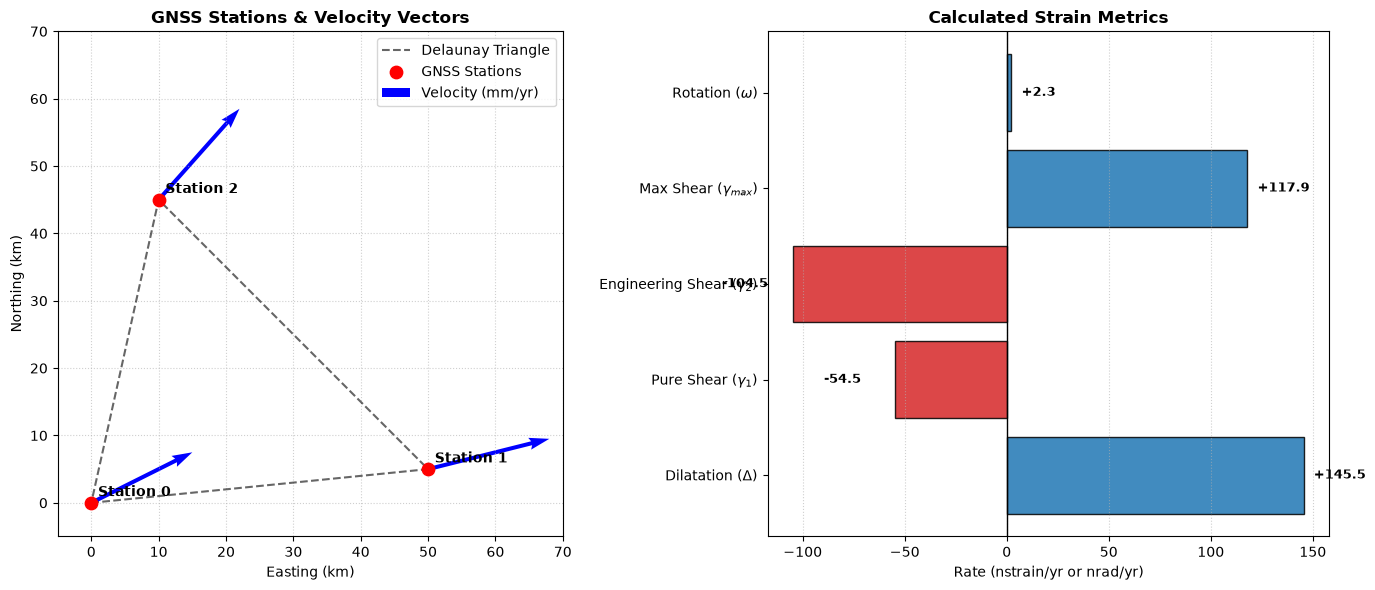

In [2]:
# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Triangulation network & Velocity vectors
triangle_x = np.append(x / 1000, x[0] / 1000)
triangle_y = np.append(y / 1000, y[0] / 1000)
ax1.plot(triangle_x, triangle_y, 'k--', alpha=0.6, label="Delaunay Triangle")

# Plot GNSS stations
ax1.scatter(x / 1000, y / 1000, color='red', s=80, zorder=5, label="GNSS Stations")
for i in range(len(x)):
    ax1.annotate(f"Station {i}", (x[i]/1000 + 1, y[i]/1000 + 1), fontsize=10, fontweight='bold')

# Velocity vectors
ax1.quiver(x / 1000, y / 1000, Vx * 1000, Vy * 1000, color='blue', scale=50, 
           width=0.008, label="Velocity (mm/yr)")

ax1.set_title("GNSS Stations & Velocity Vectors", fontsize=12, fontweight='bold')
ax1.set_xlabel("Easting (km)")
ax1.set_ylabel("Northing (km)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="upper right")
ax1.set_xlim([-5,70])
ax1.set_ylim([-5,70])
ax1.set_aspect('equal')

# Subplot 2: Strain Metrics Comparison
metrics = [
    r'Dilatation ($\Delta$)', 
    r'Pure Shear ($\gamma_1$)', 
    r'Engineering Shear ($\gamma_2$)', 
    r'Max Shear ($\gamma_{max}$)', 
    r'Rotation ($\omega$)'
]
values = [
    dilatation * to_nanostrain, 
    gamma_1 * to_nanostrain, 
    gamma_2 * to_nanostrain, 
    gamma_max * to_nanostrain, 
    rotation * to_nanostrain
]

colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
bars = ax2.barh(metrics, values, color=colors, edgecolor='black', alpha=0.85)

# Reference line at zero and value labels
ax2.axvline(0, color='black', linewidth=1)
for bar in bars:
    width = bar.get_width()
    offset = 5 if width >= 0 else -35
    ax2.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f"{width:+.1f}", va='center', fontsize=9, fontweight='bold')

ax2.set_title("Calculated Strain Metrics", fontsize=12, fontweight='bold')
ax2.set_xlabel("Rate (nstrain/yr or nrad/yr)")
ax2.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


# Least Square approach for more than 3 stations (4 and more)

Here is the translation into English:

For 4 or more stations, redundancy exists (8 equations for 6 unknowns). The design matrix $A$ becomes rectangular ($8 \times 6$). We use the normal equation for the least-squares adjustment:


$$X = (A^T W A)^{-1} A^T W L$$


In [3]:
import numpy as np

# 1. Coordinates of the 4 GNSS stations (in meters)
x = np.array([0.0, 50000.0, 10000.0, 30000.0])
y = np.array([0.0, 5000.0, 45000.0, 20000.0])

# 2. Measured horizontal velocities (in meters/year)
Vx = np.array([0.010, 0.012, 0.008, 0.0105])
Vy = np.array([0.005, 0.003, 0.009, 0.0055])

# Calculate relative coordinates (Station 0 serves as the local origin)
dx = x - x[0]
dy = y - y[0]

num_stations = len(x)
num_equations = 2 * num_stations
num_unknowns = 6

# 3. Construct rectangular design matrix A (8x6) and vector L (8x1)
A = np.zeros((num_equations, num_unknowns))
L = np.zeros((num_equations, 1))

for i in range(num_stations):
    # Rows for East velocity (Vx)
    A[2*i, 0] = 1.0     # Translation V_x0
    A[2*i, 2] = dx[i]   # Gradient dVx/dx
    A[2*i, 3] = dy[i]   # Gradient dVx/dy
    L[2*i, 0] = Vx[i]
    
    # Rows for North velocity (Vy)
    A[2*i+1, 1] = 1.0   # Translation V_y0
    A[2*i+1, 4] = dx[i] # Gradient dVy/dx
    A[2*i+1, 5] = dy[i] # Gradient dVy/dy
    L[2*i+1, 0] = Vy[i]

# 4. Define Weight matrix W (8x8) (Identity matrix for unweighted adjustment)
W = np.eye(num_equations)

# 5. Weighted Least-Squares inversion via normal equations
At_W = A.T @ W
X = np.linalg.inv(At_W @ A) @ At_W @ L
Vx0, Vy0, dVxdx, dVxdy, dVydx, dVydy = X.flatten()

# 6. Calculate Strain components
dilatation = dVxdx + dVydy
gamma_1 = dVxdx - dVydy
gamma_2 = dVxdy + dVydx
gamma_max = np.sqrt(gamma_1**2 + gamma_2**2)
rotation = 0.5 * (dVydx - dVxdy)

# 7. Calculate residuals (V = A*X - L) as quality control
residuals = A @ X - L
v_norm = np.linalg.norm(residuals)

to_nanostrain = 1e9

print("--- Results: Least-Squares Inversion (4 Stations) ---")
print(f"Dilatation (Areal Strain): {dilatation * to_nanostrain:+.2f} nstrain/yr")
print(f"Pure Shear (gamma_1): {gamma_1 * to_nanostrain:+.2f} nstrain/yr")
print(f"Engineering Shear (gamma_2): {gamma_2 * to_nanostrain:+.2f} nstrain/yr")
print(f"Maximum Total Shear: {gamma_max * to_nanostrain:.2f} nstrain/yr")
print(f"Rigid Block Rotation: {rotation * to_nanostrain:+.2f} nrad/yr")
print("---------------------------------------------------------")
print(f"Residuals L2-Norm (Model Mismatch): {v_norm:.6f} m/yr")

--- Results: Least-Squares Inversion (4 Stations) ---
Dilatation (Areal Strain): +146.75 nstrain/yr
Pure Shear (gamma_1): -53.25 nstrain/yr
Engineering Shear (gamma_2): -103.79 nstrain/yr
Maximum Total Shear: 116.65 nstrain/yr
Rigid Block Rotation: +1.90 nrad/yr
---------------------------------------------------------
Residuals L2-Norm (Model Mismatch): 0.000190 m/yr


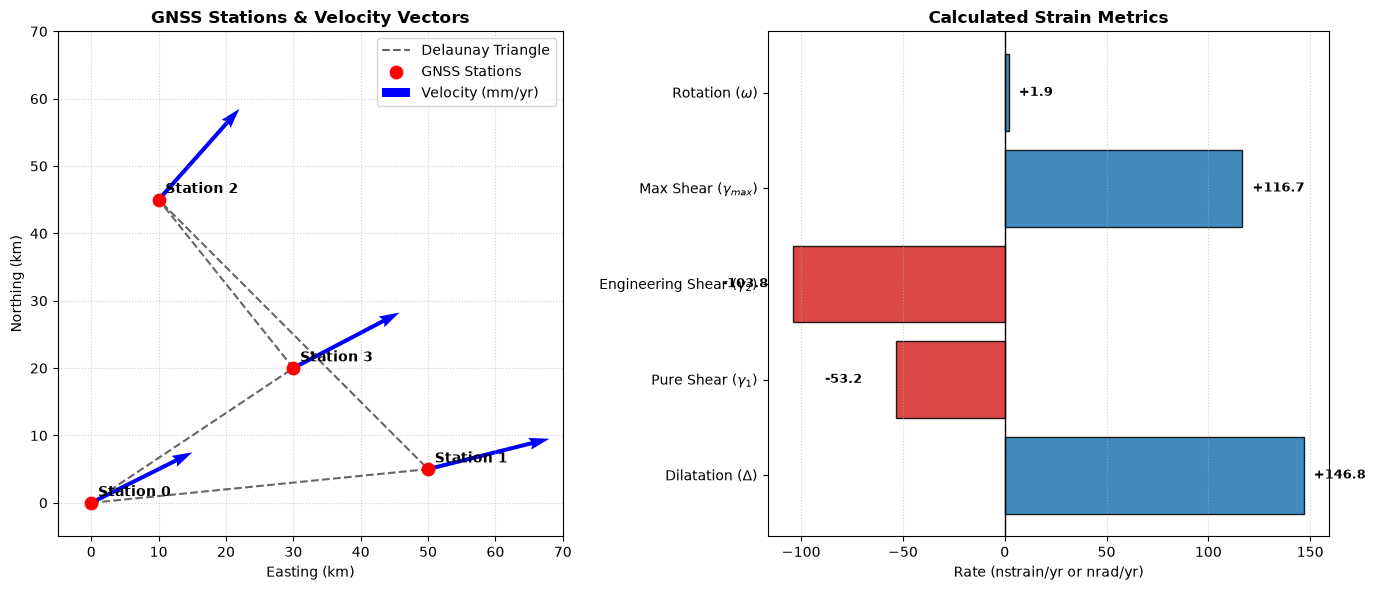

In [4]:
# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Triangulation network & Velocity vectors
triangle_x = np.append(x / 1000, x[0] / 1000)
triangle_y = np.append(y / 1000, y[0] / 1000)
ax1.plot(triangle_x, triangle_y, 'k--', alpha=0.6, label="Delaunay Triangle")

# Plot GNSS stations
ax1.scatter(x / 1000, y / 1000, color='red', s=80, zorder=5, label="GNSS Stations")
for i in range(len(x)):
    ax1.annotate(f"Station {i}", (x[i]/1000 + 1, y[i]/1000 + 1), fontsize=10, fontweight='bold')

# Velocity vectors
ax1.quiver(x / 1000, y / 1000, Vx * 1000, Vy * 1000, color='blue', scale=50, 
           width=0.008, label="Velocity (mm/yr)")

ax1.set_title("GNSS Stations & Velocity Vectors", fontsize=12, fontweight='bold')
ax1.set_xlabel("Easting (km)")
ax1.set_ylabel("Northing (km)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="upper right")
ax1.set_xlim([-5,70])
ax1.set_ylim([-5,70])
ax1.set_aspect('equal')

# Subplot 2: Strain Metrics Comparison
metrics = [
    r'Dilatation ($\Delta$)', 
    r'Pure Shear ($\gamma_1$)', 
    r'Engineering Shear ($\gamma_2$)', 
    r'Max Shear ($\gamma_{max}$)', 
    r'Rotation ($\omega$)'
]
values = [
    dilatation * to_nanostrain, 
    gamma_1 * to_nanostrain, 
    gamma_2 * to_nanostrain, 
    gamma_max * to_nanostrain, 
    rotation * to_nanostrain
]

colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
bars = ax2.barh(metrics, values, color=colors, edgecolor='black', alpha=0.85)

# Reference line at zero and value labels
ax2.axvline(0, color='black', linewidth=1)
for bar in bars:
    width = bar.get_width()
    offset = 5 if width >= 0 else -35
    ax2.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f"{width:+.1f}", va='center', fontsize=9, fontweight='bold')

ax2.set_title("Calculated Strain Metrics", fontsize=12, fontweight='bold')
ax2.set_xlabel("Rate (nstrain/yr or nrad/yr)")
ax2.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


# Triangulation

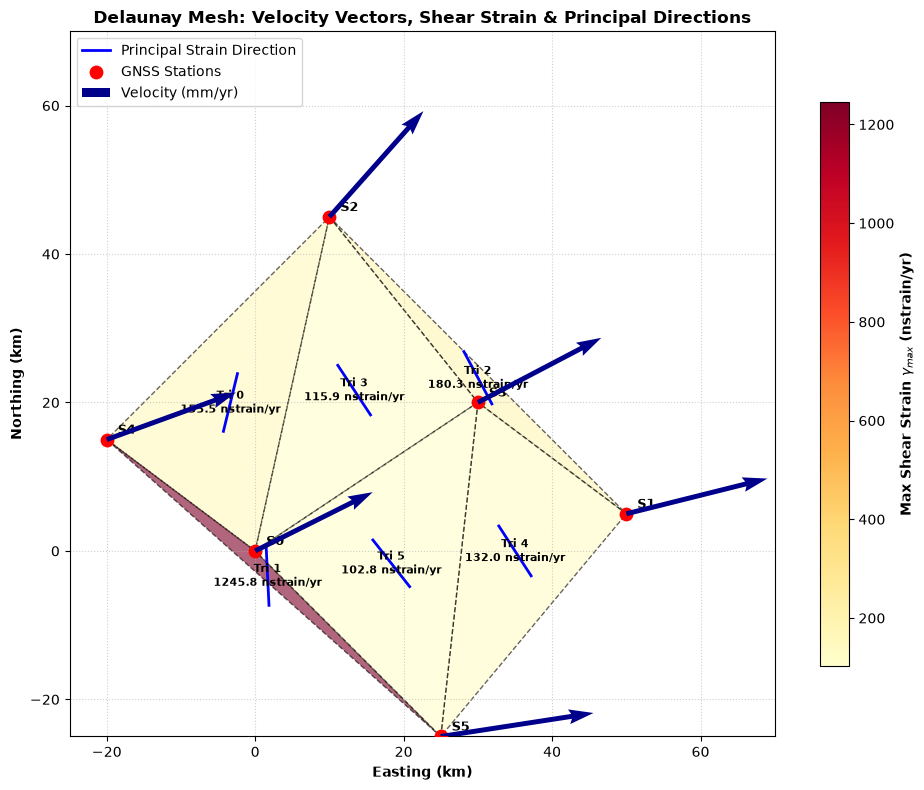

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

# 1. Coordinates of GNSS stations (in meters)
x = np.array([0.0, 50000.0, 10000.0, 30000.0, -20000.0, 25000.0])
y = np.array([0.0, 5000.0, 45000.0, 20000.0, 15000.0, -25000.0])

# 2. Horizontal velocities (in meters/year)
Vx = np.array([0.010, 0.012, 0.008, 0.0105, 0.011, 0.013])
Vy = np.array([0.005, 0.003, 0.009, 0.0055, 0.004, 0.002])

points = np.vstack((x, y)).T
tri = Delaunay(points)
to_nanostrain = 1e9

# Pre-allocate lists to store triangle results for plotting
tri_centroids = []
tri_gamma_max = []
principal_directions = []

# Process each triangle element
for tri_idx, simplex in enumerate(tri.simplices):
    idx = simplex
    dx = x[idx] - x[idx][0]
    dy = y[idx] - y[idx][0]
    
    A, L = np.zeros((6, 6)), np.zeros((6, 1))
    for i in range(3):
        A[2*i, 0], A[2*i, 2], A[2*i, 3] = 1.0, dx[i], dy[i]
        L[2*i, 0] = Vx[idx[i]]
        A[2*i+1, 1], A[2*i+1, 4], A[2*i+1, 5] = 1.0, dx[i], dy[i]
        L[2*i+1, 0] = Vy[idx[i]]
        
    X = np.linalg.solve(A, L)
    _, _, dVxdx, dVxdy, dVydx, dVydy = X.flatten()
    
    # Strain calculations
    gamma_1 = dVxdx - dVydy
    gamma_2 = dVxdy + dVydx
    gamma_max = np.sqrt(gamma_1**2 + gamma_2**2)
    
    # Principal strain direction theta (orientation of maximum extension)
    theta = 0.5 * np.arctan2(gamma_2, gamma_1)
    
    # Triangle centroid for positioning labels and directions
    centroid_x = np.mean(x[idx])
    centroid_y = np.mean(y[idx])
    
    tri_centroids.append((centroid_x, centroid_y))
    tri_gamma_max.append(gamma_max * to_nanostrain)
    principal_directions.append(theta)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Color-coded Delaunay Triangles filled by Maximum Shear Strain
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=min(tri_gamma_max), vmax=max(tri_gamma_max))

for tri_idx, simplex in enumerate(tri.simplices):
    idx = simplex
    triangle_shape = plt.Polygon(points[idx] / 1000.0, 
                                 facecolor=cmap(norm(tri_gamma_max[tri_idx])), 
                                 edgecolor='black', linestyle='--', alpha=0.6)
    ax.add_patch(triangle_shape)
    
    # Label triangle index and shear value at centroid
    cx, cy = tri_centroids[tri_idx]
    ax.text(cx / 1000.0, cy / 1000.0, 
            f"Tri {tri_idx}\n{tri_gamma_max[tri_idx]:.1f} nstrain/yr", 
            ha='center', va='center', fontsize=8, fontweight='bold')
    
    # 2. Maximum extension direction axes (cross-bars at centroid)
    theta = principal_directions[tri_idx]
    len_bar = 4.0  # length in km for display
    dx_bar = len_bar * np.cos(theta)
    dy_bar = len_bar * np.sin(theta)
    
    # Extension direction (Blue)
    ax.plot([cx/1000 - dx_bar, cx/1000 + dx_bar], 
            [cy/1000 - dy_bar, cy/1000 + dy_bar], 
            color='blue', linewidth=2, label="Principal Strain Direction" if tri_idx == 0 else "")

# 3. GNSS Stations
ax.scatter(x / 1000.0, y / 1000.0, color='red', s=80, zorder=5, label="GNSS Stations")
for i in range(len(x)):
    ax.annotate(f" S{i}", (x[i]/1000.0 + 0.8, y[i]/1000.0 + 0.8), fontsize=9, fontweight='bold')

# 4. Velocity Vectors
ax.quiver(x / 1000.0, y / 1000.0, Vx * 1000.0, Vy * 1000.0, color='darkblue', 
           scale=60, width=0.007, zorder=6, label="Velocity (mm/yr)")
ax.set_xlim([-25,70])
ax.set_ylim([-25,70])


# Colorbar for Maximum Shear Strain
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label(r'Max Shear Strain $\gamma_{max}$ (nstrain/yr)', fontweight='bold')

# Formatting
ax.set_title("Delaunay Mesh: Velocity Vectors, Shear Strain & Principal Directions", fontsize=12, fontweight='bold')
ax.set_xlabel("Easting (km)", fontweight='bold')
ax.set_ylabel("Northing (km)", fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc="upper left")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Plotting dilatation

Because dilatation can be both positive (extension/expansion) and negative (compression/contraction), we use a diverging colormap (coolwarm) centered at zero:

- Red / Warm colors: Positive dilatation ($\Delta > 0$, crustal extension/expansion).
- Blue / Cool colors: Negative dilatation ($\Delta < 0$, crustal contraction/shortening).
    

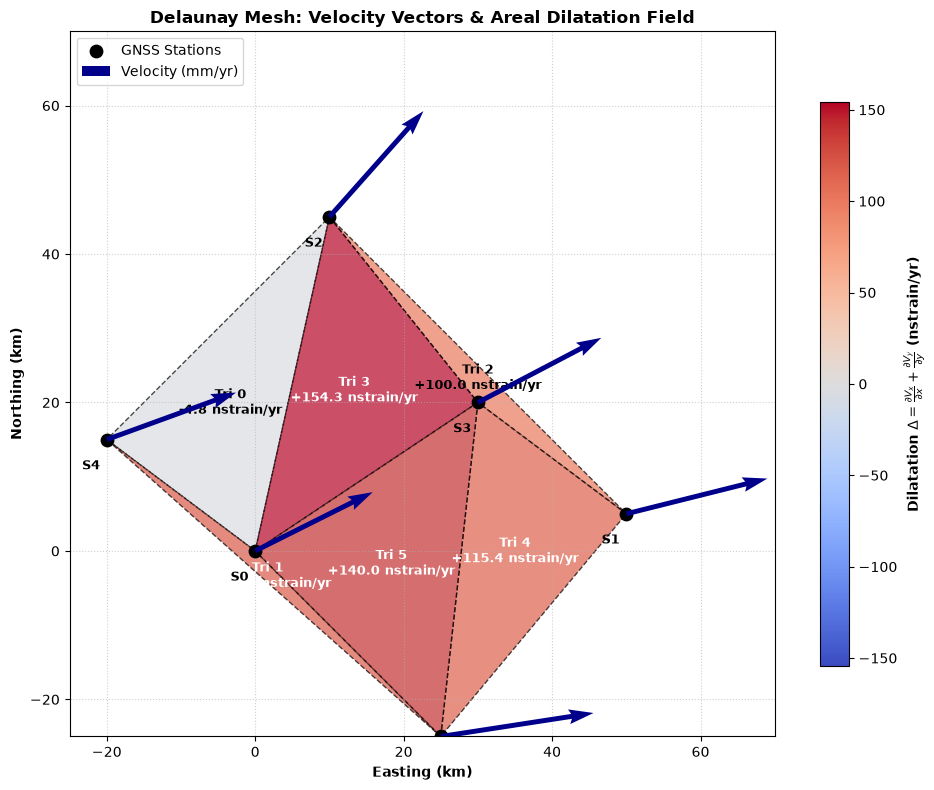

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

# 1. Coordinates of GNSS stations (in meters)
x = np.array([0.0, 50000.0, 10000.0, 30000.0, -20000.0, 25000.0])
y = np.array([0.0, 5000.0, 45000.0, 20000.0, 15000.0, -25000.0])

# 2. Horizontal velocities (in meters/year)
Vx = np.array([0.010, 0.012, 0.008, 0.0105, 0.011, 0.013])
Vy = np.array([0.005, 0.003, 0.009, 0.0055, 0.004, 0.002])

points = np.vstack((x, y)).T
tri = Delaunay(points)
to_nanostrain = 1e9

# Pre-allocate lists to store triangle results for plotting
tri_centroids = []
tri_dilatation = []

# Process each triangle element
for tri_idx, simplex in enumerate(tri.simplices):
    idx = simplex
    dx = x[idx] - x[idx][0]
    dy = y[idx] - y[idx][0]
    
    A, L = np.zeros((6, 6)), np.zeros((6, 1))
    for i in range(3):
        A[2*i, 0], A[2*i, 2], A[2*i, 3] = 1.0, dx[i], dy[i]
        L[2*i, 0] = Vx[idx[i]]
        A[2*i+1, 1], A[2*i+1, 4], A[2*i+1, 5] = 1.0, dx[i], dy[i]
        L[2*i+1, 0] = Vy[idx[i]]
        
    X = np.linalg.solve(A, L)
    _, _, dVxdx, dVxdy, dVydx, dVydy = X.flatten()
    
    # Calculate Dilatation (Areal Strain Rate)
    dilatation = dVxdx + dVydy
    
    # Triangle centroid for positioning labels
    centroid_x = np.mean(x[idx])
    centroid_y = np.mean(y[idx])
    
    tri_centroids.append((centroid_x, centroid_y))
    tri_dilatation.append(dilatation * to_nanostrain)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Diverging color scale centered at 0 (Blue = Compression, Red = Extension)
cmap = plt.cm.coolwarm
max_abs_val = max(abs(min(tri_dilatation)), abs(max(tri_dilatation)))
norm = plt.Normalize(vmin=-max_abs_val, vmax=max_abs_val)

# 1. Color-coded Delaunay Triangles filled by Dilatation
for tri_idx, simplex in enumerate(tri.simplices):
    idx = simplex
    triangle_shape = plt.Polygon(points[idx] / 1000.0, 
                                 facecolor=cmap(norm(tri_dilatation[tri_idx])), 
                                 edgecolor='black', linestyle='--', alpha=0.7)
    ax.add_patch(triangle_shape)
    
    # Label triangle index and Dilatation value at centroid
    cx, cy = tri_centroids[tri_idx]
    val = tri_dilatation[tri_idx]
    ax.text(cx / 1000.0, cy / 1000.0, 
            f"Tri {tri_idx}\n{val:+.1f} nstrain/yr", 
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='black' if abs(val) < max_abs_val * 0.7 else 'white')

# 2. GNSS Stations
ax.scatter(x / 1000.0, y / 1000.0, color='black', s=80, zorder=5, label="GNSS Stations")
for i in range(len(x)):
    ax.annotate(f" S{i}", (x[i]/1000.0 -4, y[i]/1000.0 -4), fontsize=9, fontweight='bold')

# 3. Velocity Vectors
ax.quiver(x / 1000.0, y / 1000.0, Vx * 1000.0, Vy * 1000.0, color='darkblue', 
           scale=60, width=0.007, zorder=6, label="Velocity (mm/yr)")
ax.set_xlim([-25,70])
ax.set_ylim([-25,70])

# Colorbar for Dilatation
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label(r'Dilatation $\Delta = \frac{\partial V_x}{\partial x} + \frac{\partial V_y}{\partial y}$ (nstrain/yr)', fontweight='bold')

# Formatting
ax.set_title("Delaunay Mesh: Velocity Vectors & Areal Dilatation Field", fontsize=12, fontweight='bold')
ax.set_xlabel("Easting (km)", fontweight='bold')
ax.set_ylabel("Northing (km)", fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc="upper left")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Mesh inversion with Green's function

## Compare Triangulation approaches for a 6-station network

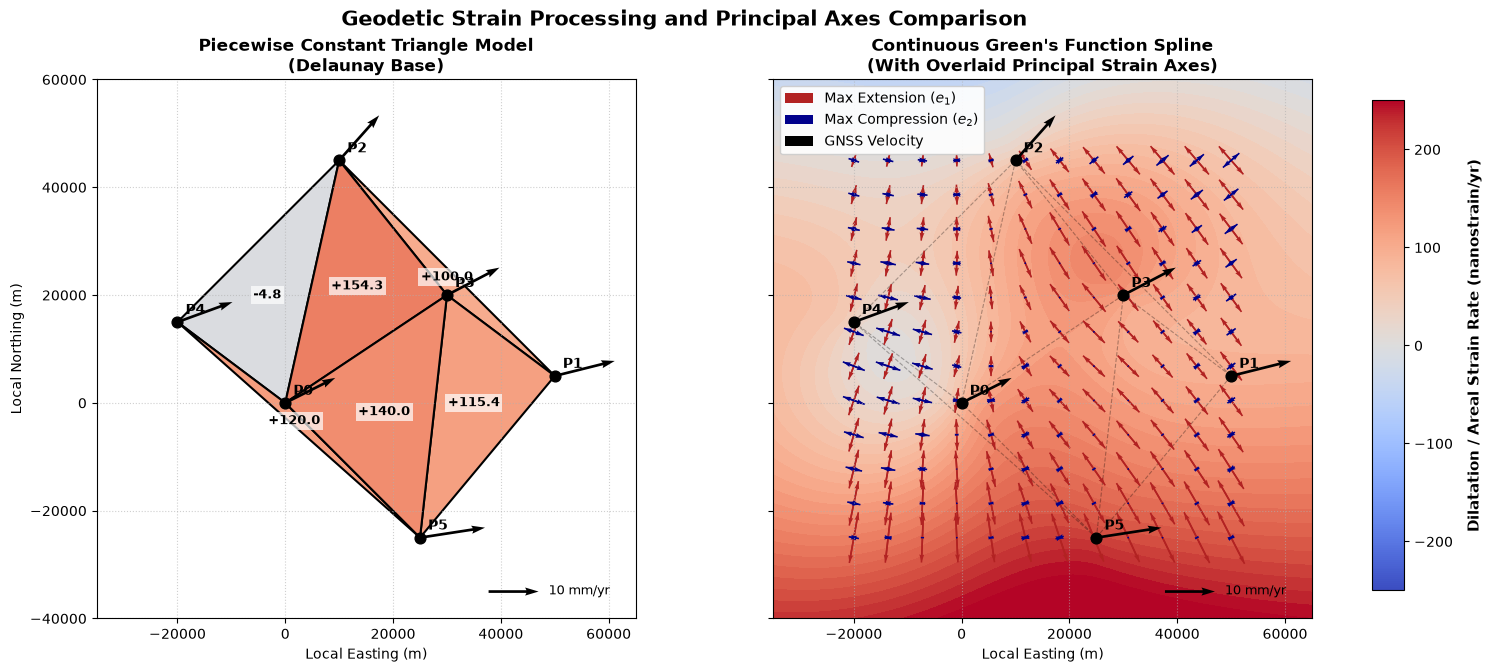

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import matplotlib.tri as mtri

# 1. Define the 6 GNSS station positions (meters) and velocities (meters/year)
x_nodes = np.array([0.0, 50000.0, 10000.0, 30000.0, -20000.0, 25000.0])
y_nodes = np.array([0.0, 5000.0, 45000.0, 20000.0, 15000.0, -25000.0])
Vx_obs = np.array([0.010, 0.012, 0.008, 0.0105, 0.011, 0.013])
Vy_obs = np.array([0.005, 0.003, 0.009, 0.0055, 0.004, 0.002]) 

points = np.vstack((x_nodes, y_nodes)).T
tri = Delaunay(points)
to_nanostrain = 1e9

# --- PRE-COMPUTE DELAUNAY TRIANGLE STRAIN VALUES ---
tri_dilatations = []
for simplex in tri.simplices:
    idx = simplex
    dx = x_nodes[idx] - x_nodes[idx[0]]
    dy = y_nodes[idx] - y_nodes[idx[0]]
        
    A = np.zeros((6, 6))
    L = np.zeros((6, 1))
    for i in range(3):
        A[2*i, 0], A[2*i, 2], A[2*i, 3] = 1.0, dx[i], dy[i]
        L[2*i, 0] = Vx_obs[idx[i]]
        A[2*i+1, 1], A[2*i+1, 4], A[2*i+1, 5] = 1.0, dx[i], dy[i]
        L[2*i+1, 0] = Vy_obs[idx[i]]
            
    X = np.linalg.solve(A, L)
    _, _, dVxdx, _, _, dVydy = X.flatten()
    tri_dilatations.append((dVxdx + dVydy) * to_nanostrain)

# --- COMPUTE GREEN'S FUNCTION FIELD ---
def greens_function(r):
    r = np.where(r == 0, 1e-10, r)
    return (r**2) * (np.log(r) - 1.0)

def greens_derivative_x(dx, dy, r):
    r = np.where(r == 0, 1e-10, r)
    return dx * (2.0 * np.log(r) - 1.0)

def greens_derivative_y(dx, dy, r):
    r = np.where(r == 0, 1e-10, r)
    return dy * (2.0 * np.log(r) - 1.0)

num_stations = len(x_nodes)
G = np.zeros((num_stations, num_stations))
for i in range(num_stations):
    for j in range(num_stations):
        r = np.sqrt((x_nodes[i] - x_nodes[j])**2 + (y_nodes[i] - y_nodes[j])**2)
        G[i, j] = greens_function(r)

lambda_smooth = 1e-6
alpha = np.linalg.solve(G + np.eye(num_stations) * lambda_smooth, Vx_obs)
beta = np.linalg.solve(G + np.eye(num_stations) * lambda_smooth, Vy_obs)

# Continuous high-resolution grid for the heatmap background
grid_x = np.linspace(-35000, 65000, 150)
grid_y = np.linspace(-40000, 60000, 150)
X_grid, Y_grid = np.meshgrid(grid_x, grid_y)
dil_grid = np.zeros_like(X_grid)

# Coarser grid specifically to prevent overlapping quiver arrows
quiver_x = np.linspace(-20000, 50000, 12)
quiver_y = np.linspace(-25000, 45000, 12)
X_q, Y_q = np.meshgrid(quiver_x, quiver_y)

# Arrays to hold quiver properties
q_ex_u, q_ex_v = np.zeros_like(X_q), np.zeros_like(X_q) # e1 vector components
q_co_u, q_co_v = np.zeros_like(X_q), np.zeros_like(X_q) # e2 vector components

# Compute background grid
for r_idx in range(X_grid.shape[0]):
    for c_idx in range(X_grid.shape[1]):
        ex, ey = X_grid[r_idx, c_idx], Y_grid[r_idx, c_idx]
        dx_eval, dy_eval = ex - x_nodes, ey - y_nodes
        r_eval = np.sqrt(dx_eval**2 + dy_eval**2)
        dVxdx = np.sum(alpha * greens_derivative_x(dx_eval, dy_eval, r_eval))
        dVydy = np.sum(beta * greens_derivative_y(dx_eval, dy_eval, r_eval))
        dil_grid[r_idx, c_idx] = (dVxdx + dVydy) * to_nanostrain

# Compute quivers grid
for r_idx in range(X_q.shape[0]):
    for c_idx in range(X_q.shape[1]):
        qx, qy = X_q[r_idx, c_idx], Y_q[r_idx, c_idx]
        dx_eval, dy_eval = qx - x_nodes, qy - y_nodes
        r_eval = np.sqrt(dx_eval**2 + dy_eval**2)
        
        # Calculate full velocity gradient tensor at point
        dVxdx = np.sum(alpha * greens_derivative_x(dx_eval, dy_eval, r_eval))
        dVxdy = np.sum(alpha * greens_derivative_y(dx_eval, dy_eval, r_eval))
        dVydx = np.sum(beta * greens_derivative_x(dx_eval, dy_eval, r_eval))
        dVydy = np.sum(beta * greens_derivative_y(dx_eval, dy_eval, r_eval))
        
        # Build symmetric strain tensor components
        e_xx = dVxdx
        e_yy = dVydy
        e_xy = 0.5 * (dVxdy + dVydx)
        
        # Compute principal strain values (Eigenvalues)
        center = 0.5 * (e_xx + e_yy)
        radius = np.sqrt((0.5 * (e_xx - e_yy))**2 + e_xy**2)
        e1 = center + radius # Maximum extension
        e2 = center - radius # Maximum compression
        
        # Compute orientation azimuth angle theta (Eigenvectors)
        theta = 0.5 * np.arctan2(2.0 * e_xy, e_xx - e_yy)
        
        # Store directional unit components scaled by magnitude
        q_ex_u[r_idx, c_idx] = np.cos(theta) * (e1 * to_nanostrain)
        q_ex_v[r_idx, c_idx] = np.sin(theta) * (e1 * to_nanostrain)
        
        q_co_u[r_idx, c_idx] = np.cos(theta + np.pi/2.0) * (e2 * to_nanostrain)
        q_co_v[r_idx, c_idx] = np.sin(theta + np.pi/2.0) * (e2 * to_nanostrain)

# --- MATPLOTLIB SIDE-BY-SIDE PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
cmap_style = 'coolwarm'
vmin, vmax = -250, 250 
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# Scale parameter for GNSS station velocity vectors (m/yr to plot units)
vel_scale = 0.00025 
vel_scale_points = 0.02

# Left Panel: Standard Independent Triangle Approach
ax1 = axes[0]
matplotlib_triang = mtri.Triangulation(x_nodes, y_nodes, tri.simplices)
trip = ax1.tripcolor(matplotlib_triang, facecolors=tri_dilatations, cmap=cmap_style, norm=norm, edgecolors='k', lw=1.5)
ax1.scatter(x_nodes, y_nodes, color='black', s=60, zorder=3)
ax1.set_title("Piecewise Constant Triangle Model\n(Delaunay Base)", fontsize=12, fontweight='bold')

for tri_idx, simplex in enumerate(tri.simplices):
    cx = np.mean(x_nodes[simplex])
    cy = np.mean(y_nodes[simplex])
    ax1.text(cx, cy, f"{tri_dilatations[tri_idx]:+.1f}", ha='center', va='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle="square,pad=0.2", fc="w", alpha=0.7, ec="none"))

# Overlay observed GNSS velocity arrows on Left Panel
q_vel1 = ax1.quiver(x_nodes, y_nodes, Vx_obs, Vy_obs, color='black', scale=vel_scale_points, 
                    scale_units='inches', width=0.005, zorder=4, label='GNSS Velocity')
ax1.quiverkey(q_vel1, 0.82, 0.05, 0.010, r'$10\text{ mm/yr}$', labelpos='E', coordinates='axes', 
              fontproperties={'weight': 'bold', 'size': 9})

# Right Panel: Continuous Spline Approach + Overlaid Principal Quivers
ax2 = axes[1]
levels = np.linspace(vmin, vmax, 51)
contour = ax2.contourf(X_grid, Y_grid, dil_grid, levels=levels, cmap=cmap_style, norm=norm, extend='both')
ax2.triplot(x_nodes, y_nodes, tri.simplices, color='black', lw=0.8, alpha=0.3, ls='--')
ax2.scatter(x_nodes, y_nodes, color='black', s=60, zorder=3)

# Plot e1 (Extensional Axes) - Red, double-headed representation via pivot='middle'
scale_factor = 2000 # Adjusts visual length of strain arrows relative to coordinate meters
ax2.quiver(X_q, Y_q, q_ex_u, q_ex_v, color='firebrick', scale=scale_factor, pivot='middle', 
           width=0.003, headwidth=3, label=r'Max Extension ($e_1$)')
ax2.quiver(X_q, Y_q, -q_ex_u, -q_ex_v, color='firebrick', scale=scale_factor, pivot='middle', 
           width=0.003, headwidth=3)

# Plot e2 (Compressional Axes) - Blue
ax2.quiver(X_q, Y_q, q_co_u, q_co_v, color='darkblue', scale=scale_factor, pivot='middle', 
           width=0.003, headwidth=3, label=r'Max Compression ($e_2$)')
ax2.quiver(X_q, Y_q, -q_co_u, -q_co_v, color='darkblue', scale=scale_factor, pivot='middle', 
           width=0.003, headwidth=3)

# Overlay observed GNSS velocity arrows on Right Panel
q_vel2 = ax2.quiver(x_nodes, y_nodes, Vx_obs, Vy_obs, color='black', scale=vel_scale_points, 
                    scale_units='inches', width=0.005, zorder=4, label='GNSS Velocity')
ax2.quiverkey(q_vel2, 0.82, 0.05, 0.010, r'$10\text{ mm/yr}$', labelpos='E', coordinates='axes', 
              fontproperties={'weight': 'bold', 'size': 9})

ax2.set_title("Continuous Green's Function Spline\n(With Overlaid Principal Strain Axes)", fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', facecolor='white', framealpha=0.9)

# Format layouts
for ax in axes:
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel("Local Easting (m)")
axes[0].set_ylabel("Local Northing (m)")

for i in range(num_stations):
    for ax in axes:
        ax.text(x_nodes[i] + 1500, y_nodes[i] + 1500, f"P{i}", fontsize=10, fontweight='bold')

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap_style, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Dilatation / Areal Strain Rate (nanostrain/yr)", fontsize=11, fontweight='bold', labelpad=10)

plt.suptitle("Geodetic Strain Processing and Principal Axes Comparison", fontsize=15, fontweight='bold', y=0.98)
plt.show()

# Compare different methods for Stran interpolation

1. **Delaunay Triangulation:** Best for local, dense networks where station spacing is uniform, and data quality is high. It avoids parameter tuning ($\lambda$ or distance thresholds) but yields step-like boundary jumps across triangle edges.
2. **Thin-Plate Splines (Green's Function):** Best for continuous strain field mapping over regional spatial scales. Incorporating regularization ($\lambda$) dampens noise from individual station errors.
3. **Shen et al. Distance-Weighted LSQ:** Preferred when station distribution is irregular or clustered. It adjusts the smoothing decay $D$ based on local station density, providing balanced spatial resolution across varying network densities.

| Feature / Method | 1. Delaunay Triangulation (Piecewise Linear) | 2. Thin-Plate Spline (Green's Function) | 3. Distance-Weighted Nearest Neighbors (Shen et al.) | 4. Least-Squares Collocation (Kriging) |
| --- | --- | --- | --- | --- |
| **Continuity** | $C^0$ Velocity, $C^{-1}$ Discontinuous Strain | $C^2$ Continuous Velocity & Strain | $C^\infty$ Smooth Local Field | $C^1/C^2$ Smooth (Model-dependent) |
| **Smoothing / Noise Handling** | None (exact interpolation, sensitive to noise) | Tikhonov Regularization ($\lambda$) | Distance-based Gaussian / Decay weighting | Covariance function based on data noise |
| **Calculation Mechanics** | Linear system per triangle ($3\times 3$) | Global Radial Basis System | Weighted LSQ at each evaluation grid node | Stochastic signal + noise separation |
| **Extrapolation Reliability** | Fails outside the convex hull | May diverge rapidly away from nodes | Decays gracefully to regional mean | Decays to zero signal prior |

Method                         | Dilatation (nstr/yr)   | Rotation Rate (nstr/yr)
--------------------------------------------------------------------------------
1. Delaunay Triangulation      | 154.35                 | 3.26                  
2. Thin-Plate Spline (Green)   | 117.21                 | -4.03                 
3. Shen et al. Distance LSQ    | 112.73                 | 15.65                 


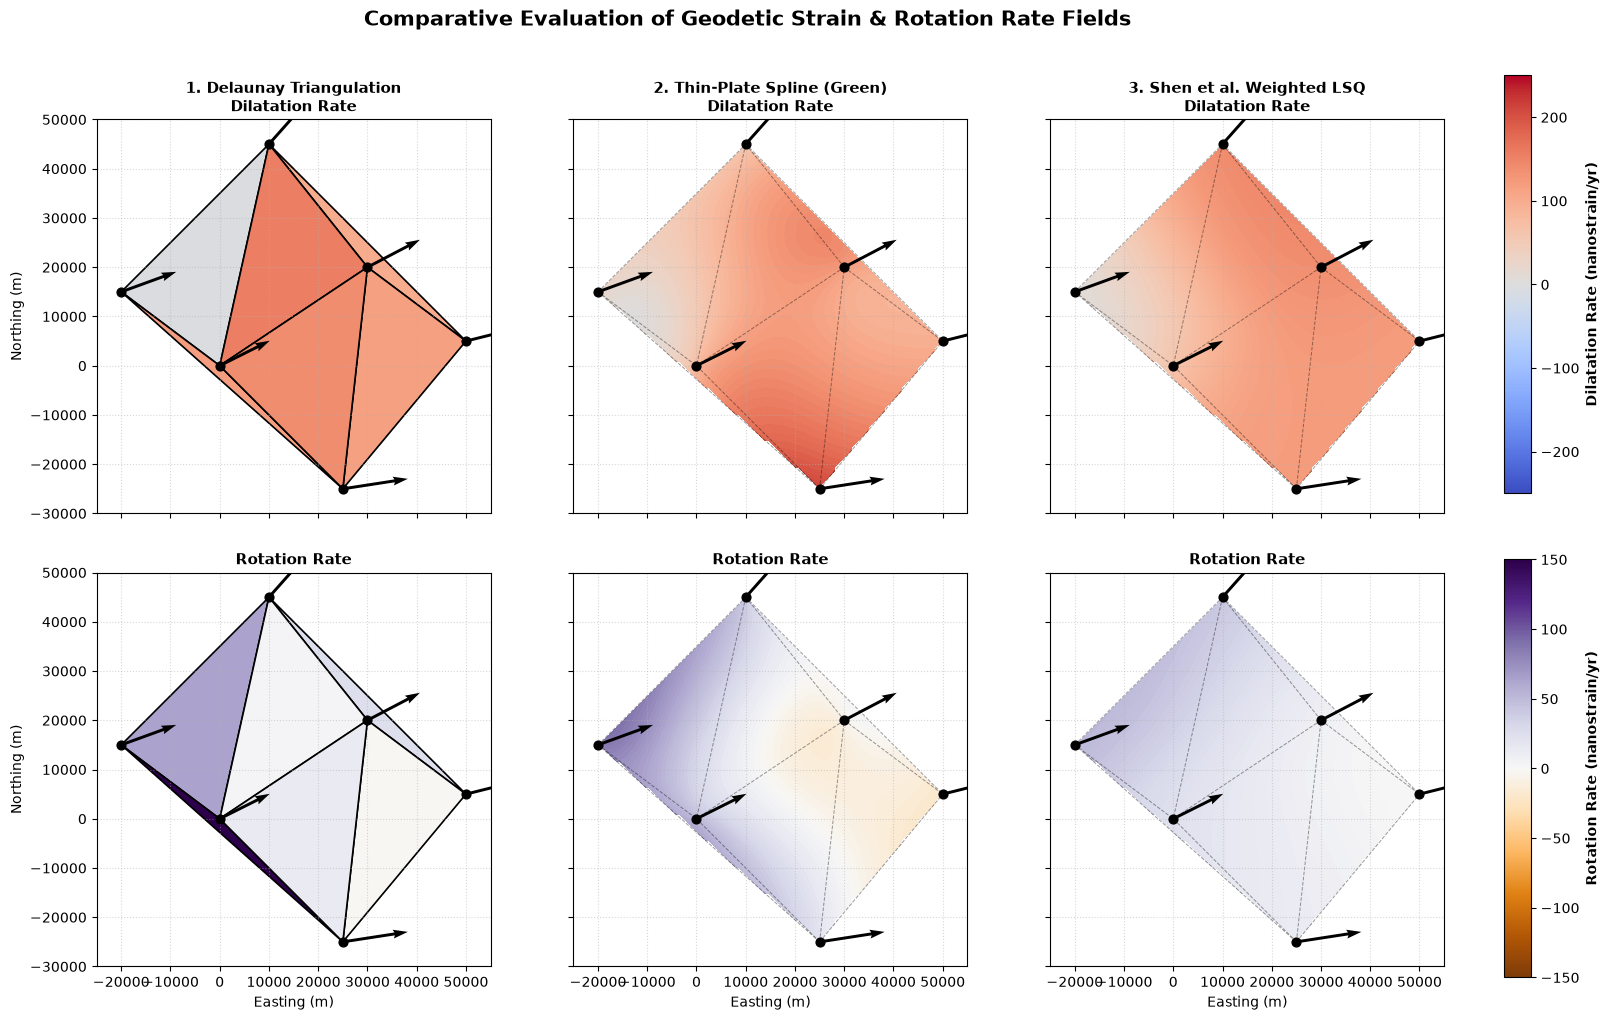

In [9]:
import numpy as np
import scipy.spatial as spatial
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# ==============================================================================
# 1. NETWORK & VELOCITY DATA
# ==============================================================================
x_nodes = np.array([0.0, 50000.0, 10000.0, 30000.0, -20000.0, 25000.0])  # meters
y_nodes = np.array([0.0, 5000.0, 45000.0, 20000.0, 15000.0, -25000.0]) # meters
Vx = np.array([0.010, 0.012, 0.008, 0.0105, 0.011, 0.013])             # m/yr
Vy = np.array([0.005, 0.003, 0.009, 0.0055, 0.004, 0.002])             # m/yr

num_st = len(x_nodes)
to_nanostrain = 1e9

# Setup Delaunay Mesh
pts = np.vstack((x_nodes, y_nodes)).T
tri_mesh = spatial.Delaunay(pts)

# Setup Spatial Grid for Continuous Models (Spline & Shen)
grid_x = np.linspace(-25000, 55000, 120)
grid_y = np.linspace(-30000, 50000, 120)
X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

# Mask grid outside convex hull for clean presentation
hull_path = spatial.ConvexHull(pts)
tri_path = plt.Polygon(pts[hull_path.vertices]).get_path()
grid_pts = np.vstack((X_grid.flatten(), Y_grid.flatten())).T
inside_hull = tri_path.contains_points(grid_pts).reshape(X_grid.shape)

# ==============================================================================
# 2. METHOD 1: DELAUNAY TRIANGULATION (PIECEWISE CONSTANT PER TRIANGLE)
# ==============================================================================
num_tris = len(tri_mesh.simplices)
dil_tri_vals = np.zeros(num_tris)
rot_tri_vals = np.zeros(num_tris)

for idx, simplex in enumerate(tri_mesh.simplices):
    dx = x_nodes[simplex] - x_nodes[simplex[0]]
    dy = y_nodes[simplex] - y_nodes[simplex[0]]
    
    A_t = np.zeros((6, 6))
    L_t = np.zeros((6, 1))
    for i in range(3):
        A_t[2*i, 0], A_t[2*i, 2], A_t[2*i, 3] = 1.0, dx[i], dy[i]
        L_t[2*i, 0] = Vx[simplex[i]]
        A_t[2*i+1, 1], A_t[2*i+1, 4], A_t[2*i+1, 5] = 1.0, dx[i], dy[i]
        L_t[2*i+1, 0] = Vy[simplex[i]]
        
    X_sol = np.linalg.solve(A_t, L_t).flatten()
    _, _, dvx_dx, dvx_dy, dvy_dx, dvy_dy = X_sol
    
    dil_tri_vals[idx] = (dvx_dx + dvy_dy) * to_nanostrain
    rot_tri_vals[idx] = 0.5 * (dvy_dx - dvx_dy) * to_nanostrain

# Matplotlib triangulation structure for tripcolor
mtri_mesh = mtri.Triangulation(x_nodes, y_nodes, tri_mesh.simplices)

# ==============================================================================
# 3. METHOD 2: THIN-PLATE SPLINE GREEN'S FUNCTION
# ==============================================================================
def g_deriv_x(dx, dy, r):
    r = np.where(r == 0, 1e-10, r)
    return dx * (2.0 * np.log(r) - 1.0)

def g_deriv_y(dx, dy, r):
    r = np.where(r == 0, 1e-10, r)
    return dy * (2.0 * np.log(r) - 1.0)

G = np.zeros((num_st, num_st))
for i in range(num_st):
    for j in range(num_st):
        r = np.sqrt((x_nodes[i] - x_nodes[j])**2 + (y_nodes[i] - y_nodes[j])**2)
        G[i, j] = (r**2) * (np.log(np.where(r == 0, 1e-10, r)) - 1.0)

alpha = np.linalg.solve(G + np.eye(num_st) * 1e-6, Vx)
beta  = np.linalg.solve(G + np.eye(num_st) * 1e-6, Vy)

dil_tps_grid = np.zeros_like(X_grid)
rot_tps_grid = np.zeros_like(X_grid)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        gx, gy = X_grid[i, j], Y_grid[i, j]
        dx_e, dy_e = gx - x_nodes, gy - y_nodes
        r_e = np.sqrt(dx_e**2 + dy_e**2)
        
        dvx_dx = np.sum(alpha * g_deriv_x(dx_e, dy_e, r_e))
        dvx_dy = np.sum(alpha * g_deriv_y(dx_e, dy_e, r_e))
        dvy_dx = np.sum(beta * g_deriv_x(dx_e, dy_e, r_e))
        dvy_dy = np.sum(beta * g_deriv_y(dx_e, dy_e, r_e))
        
        dil_tps_grid[i, j] = (dvx_dx + dvy_dy) * to_nanostrain
        rot_tps_grid[i, j] = 0.5 * (dvy_dx - dvx_dy) * to_nanostrain

# Mask out-of-bounds region
dil_tps_grid[~inside_hull] = np.nan
rot_tps_grid[~inside_hull] = np.nan

# ==============================================================================
# 4. METHOD 3: SHEN ET AL. DISTANCE-WEIGHTED LSQ
# ==============================================================================
D_decay = 25000.0  # Smoothing decay scale (meters)
dil_shen_grid = np.zeros_like(X_grid)
rot_shen_grid = np.zeros_like(X_grid)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        gx, gy = X_grid[i, j], Y_grid[i, j]
        dists = np.sqrt((x_nodes - gx)**2 + (y_nodes - gy)**2)
        weights_1d = np.exp(-dists**2 / (2 * D_decay**2))
        
        W_full = np.diag(np.repeat(weights_1d, 2))
        A_shen = np.zeros((2 * num_st, 6))
        L_shen = np.zeros((2 * num_st, 1))
        
        for k in range(num_st):
            dx_k, dy_k = x_nodes[k] - gx, y_nodes[k] - gy
            A_shen[2*k]     = [1.0, 0.0, dx_k, dy_k, 0.0,  0.0 ]
            L_shen[2*k]     = Vx[k]
            A_shen[2*k+1]   = [0.0, 1.0, 0.0,  0.0,  dx_k, dy_k]
            L_shen[2*k+1]   = Vy[k]
            
        A_w = W_full @ A_shen
        L_w = W_full @ L_shen
        
        X_sh, _, _, _ = np.linalg.lstsq(A_w, L_w, rcond=None)
        _, _, dvx_dx, dvx_dy, dvy_dx, dvy_dy = X_sh.flatten()
        
        dil_shen_grid[i, j] = (dvx_dx + dvy_dy) * to_nanostrain
        rot_shen_grid[i, j] = 0.5 * (dvy_dx - dvx_dy) * to_nanostrain

dil_shen_grid[~inside_hull] = np.nan
rot_shen_grid[~inside_hull] = np.nan


# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================
print(f"{'Method':<30} | {'Dilatation (nstr/yr)':<22} | {'Rotation Rate (nstr/yr)':<22}")
print("-" * 80)
print(f"{'1. Delaunay Triangulation':<30} | {dil_tri:<22.2f} | {rot_tri:<22.2f}")
print(f"{'2. Thin-Plate Spline (Green)':<30} | {dil_tps:<22.2f} | {rot_tps:<22.2f}")
print(f"{'3. Shen et al. Distance LSQ':<30} | {dil_shen:<22.2f} | {rot_shen:<22.2f}")

# ==============================================================================
# 5. MATPLOTLIB COMPARISON PLOTTING (2x3 GRID)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)

# Color Normalizations
norm_dil = plt.Normalize(vmin=-250, vmax=250)
norm_rot = plt.Normalize(vmin=-150, vmax=150)
cmap_dil, cmap_rot = 'coolwarm', 'PuOr'
vel_scale = 0.0003  # Station velocity arrow scale
vel_scale2 = 0.02

def format_panel(ax, title):
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.triplot(x_nodes, y_nodes, tri_mesh.simplices, color='black', lw=0.7, alpha=0.4, ls='--')
    ax.scatter(x_nodes, y_nodes, color='black', s=40, zorder=4)
    q = ax.quiver(x_nodes, y_nodes, Vx, Vy, color='black', scale=vel_scale2, scale_units='inches', zorder=5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.5)

# --- TOP ROW: DILATATION RATE ---
# 1. Delaunay Dilatation
axes[0, 0].tripcolor(mtri_mesh, facecolors=dil_tri_vals, cmap=cmap_dil, norm=norm_dil, edgecolors='k', lw=1.2)
format_panel(axes[0, 0], "1. Delaunay Triangulation\nDilatation Rate")

# 2. Thin-Plate Spline Dilatation
axes[0, 1].contourf(X_grid, Y_grid, dil_tps_grid, levels=50, cmap=cmap_dil, norm=norm_dil)
format_panel(axes[0, 1], "2. Thin-Plate Spline (Green)\nDilatation Rate")

# 3. Shen et al. Dilatation
axes[0, 2].contourf(X_grid, Y_grid, dil_shen_grid, levels=50, cmap=cmap_dil, norm=norm_dil)
format_panel(axes[0, 2], "3. Shen et al. Weighted LSQ\nDilatation Rate")

# --- BOTTOM ROW: ROTATION RATE ---
# 4. Delaunay Rotation
axes[1, 0].tripcolor(mtri_mesh, facecolors=rot_tri_vals, cmap=cmap_rot, norm=norm_rot, edgecolors='k', lw=1.2)
format_panel(axes[1, 0], "Rotation Rate")

# 5. Thin-Plate Spline Rotation
axes[1, 1].contourf(X_grid, Y_grid, rot_tps_grid, levels=50, cmap=cmap_rot, norm=norm_rot)
format_panel(axes[1, 1], "Rotation Rate")

# 6. Shen et al. Rotation
axes[1, 2].contourf(X_grid, Y_grid, rot_shen_grid, levels=50, cmap=cmap_rot, norm=norm_rot)
format_panel(axes[1, 2], "Rotation Rate")

# Formatting Axes Labels
for ax in axes[1, :]:
    ax.set_xlabel("Easting (m)", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("Northing (m)", fontsize=10)

# Add Colorbars
cbar_ax_dil = fig.add_axes([0.92, 0.54, 0.015, 0.38])
sm_dil = plt.cm.ScalarMappable(cmap=cmap_dil, norm=norm_dil)
cbar_dil = fig.colorbar(sm_dil, cax=cbar_ax_dil)
cbar_dil.set_label("Dilatation Rate (nanostrain/yr)", fontweight='bold', fontsize=10)

cbar_ax_rot = fig.add_axes([0.92, 0.10, 0.015, 0.38])
sm_rot = plt.cm.ScalarMappable(cmap=cmap_rot, norm=norm_rot)
cbar_rot = fig.colorbar(sm_rot, cax=cbar_ax_rot)
cbar_rot.set_label("Rotation Rate (nanostrain/yr)", fontweight='bold', fontsize=10)

plt.suptitle("Comparative Evaluation of Geodetic Strain & Rotation Rate Fields", fontsize=15, fontweight='bold', y=0.98)
plt.subplots_adjust(right=0.90, hspace=0.15, wspace=0.08)
plt.show()